### Datos sinteticos 
### libreria SDV
fecha: 05/junio
Jose Valentin Contreras Gomez

In [1]:
import pandas as pd
import numpy as mp
import random

In [2]:
import sdv
import sdmetrics

In [3]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [4]:
from sdmetrics.reports.single_table import QualityReport

In [5]:
print("SDV: ", sdv.__version__)
print("SDMetrics: ", sdmetrics.__version__)

SDV:  1.37.0
SDMetrics:  0.28.0


In [6]:
# Creamos una tabla de datos real como base para la generacion de datos sinteticos
dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1,2,3,4,5,6,7,8,9,10],
        "edad": [17,18,19,25,32,42,70,28,23,22],
        "ingreso_mensual": [1800, 2000,2500,15000,18000,35000,7000,15000,4000,5000],
        "ciudad" : ["Potrero Nuevo", "Atoyac", "Cuichapa", "Cordoba", "Cuitlahuac", "Orizaba", "Yanga", "Carrillo Puerto", "Zapote", "Fortin"]
    }
)

In [7]:
dfClientes

,cliente_id,edad,ingreso_mensual,ciudad
0,1,17,1800,Potrero Nuevo
1,2,18,2000,Atoyac
2,3,19,2500,Cuichapa
3,4,25,15000,Cordoba
4,5,32,18000,Cuitlahuac
5,6,42,35000,Orizaba
6,7,70,7000,Yanga
7,8,28,15000,Carrillo Puerto
8,9,23,4000,Zapote
9,10,22,5000,Fortin


### obtener los metadata del DataFrame generado

In [8]:
#creamos una instancia de SingleTableMetadata
metadata = SingleTableMetadata()

In [9]:
metadata.detect_from_dataframe(
    data= dfClientes
)

In [10]:
metadata.to_dict()

{'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'primary_key': 'cliente_id',
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

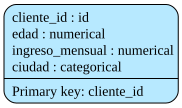

In [11]:
metadata.visualize()

In [12]:
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

C:\Users\val\anaconda\envs\Extraccion9AVS\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\Users\val\anaconda\envs\Extraccion9AVS\Lib\site-packages\sdv\single_table\base.py:138: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [13]:
# Entrenamos el sintetizador con los datos "Reales"
sintetizador.fit(
    dfClientes
)

In [14]:
dfClientes_falsos = sintetizador.sample(
    num_rows=200
)

In [15]:
dfClientes_falsos.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,39,26390,Zapote
1,4918803,19,3912,Zapote
2,1900081,21,6413,Yanga
3,531516,20,2558,Yanga
4,10211768,37,14819,Fortin


In [16]:
dfClientes_falsos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       200 non-null    int64 
 1   edad             200 non-null    int64 
 2   ingreso_mensual  200 non-null    int64 
 3   ciudad           200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [17]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,8.765887e+06,26.035000,10667.460000
std,4.707538e+06,12.553154,9166.046225
min,4.660500e+04,18.000000,2000.000000
25%,5.085226e+06,18.000000,2731.750000
50%,9.212590e+06,20.000000,7998.000000
75%,1.279456e+07,30.000000,16217.000000
max,1.677377e+07,70.000000,35000.000000


In [18]:
dfClientes.describe()

,cliente_id,edad,ingreso_mensual
count,10.00000,10.000000,10.000000
mean,5.50000,29.600000,10530.000000
std,3.02765,16.063762,10507.568701
min,1.00000,17.000000,1800.000000
25%,3.25000,19.750000,2875.000000
50%,5.50000,24.000000,6000.000000
75%,7.75000,31.000000,15000.000000
max,10.00000,70.000000,35000.000000


###evaluamos los datos para validar
1. Parecido entre las columnos (Columns Shapes Score)
2. parecido entre las relaciones de las columnas (Evaluating Column Per Trends)
3. Evaluacion del dataset general

In [19]:
# Evaluamos la calidad de los datos
# Creamos una instancia de QualityReport
reporte = QualityReport()

In [20]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 315.19it/s]|
Column Shapes Score: 74.83%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 71.50it/s]|
Column Pair Trends Score: 22.0%

Overall Score (Average): 48.42%



### Puntos de referencia
|Score | Interpretacion |
-------|----------------
|1  | Identicas |
|0.9| Muy similar |
|0.7| Similar |
|0.6| Diferencias visibles |
|< 0.5| Muy diferentes |